<h4>Setup</h4>

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import QuantLib as ql

Also, define a helper function to make the notebook less verbose.

In [2]:
def set_unit_square(ax):
    ax.axis('scaled')
    ax.set_xlim([0,1])
    ax.set_ylim([0,1])

In [3]:
rng = ql.MersenneTwisterUniformRng(42)

In [4]:
xs = []
ys = []
for i in range(2047):
    xs.append(rng.next().value())
    ys.append(rng.next().value())

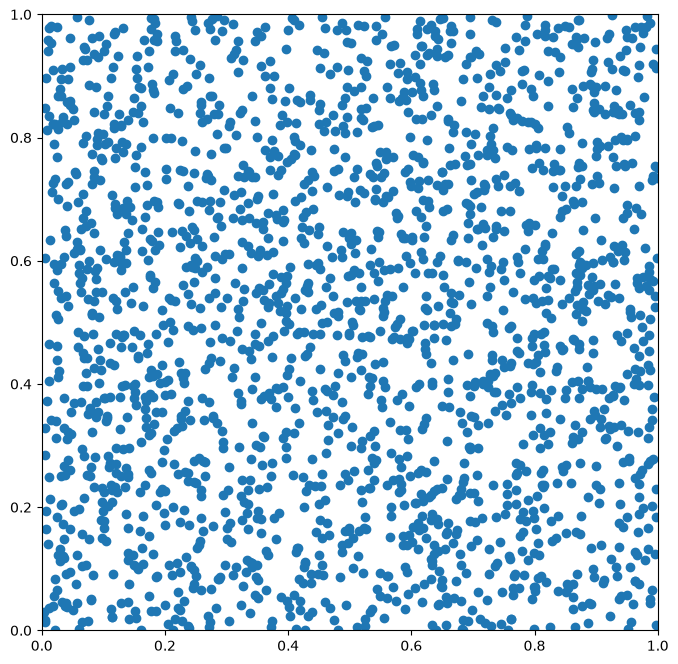

In [5]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(1,1,1)
set_unit_square(ax)
ax.plot(xs,ys,'o')
plt.show()

The same doesn’t hold for quasi-random numbers, for which each sample is correlated to the one
that follows it in order to cover the domain evenly. We can see this by plotting the sequence of Sobol
numbers generated to cover the 1-dimensional unit interval:

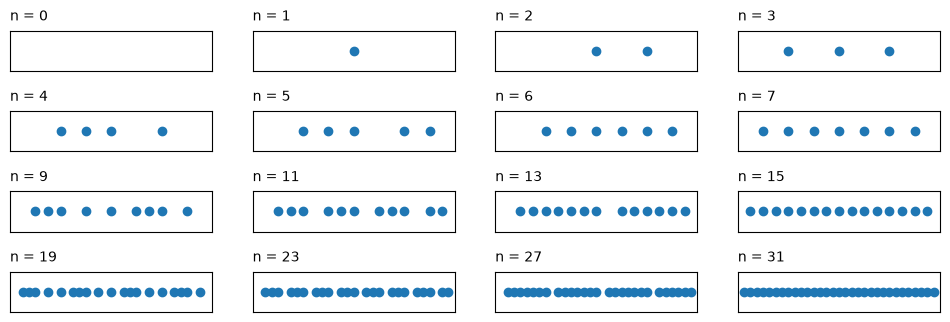

In [6]:
fig = plt.figure(figsize=(12,4))
for i, n in enumerate([0, 1, 2, 3, 4, 5, 6, 7, 9, 11, 13, 15, 19, 23, 27, 31]):
    rng = ql.SobolRsg(1)
    xs = [rng.nextSequence().value()[0] for j in range(n)]
    ax = fig.add_subplot(4, 4, i+1)
    ax.axis('scaled')
    ax.set_xlim([0, 1])
    ax.set_ylim([-0.1, 0.1])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.plot(xs, [0]*len(xs),'o')
    ax.text(0.0, 0.15, 'n = %d' % n)
    

The points are not added randomly at all, but in a predetermined sequence. This ruins the random properties of the sequence when used with the wrong dimensionality. (You can also see how an even coverage is only obtained for a number of samples of the form n = 2^i − 1 for some i.)

In [7]:
rng = ql.SobolRsg(1)

In [8]:
xs = []
ys = []
for i in range(2047):
    xs.append(rng.nextSequence().value()[0])
    ys.append(rng.nextSequence().value()[0])
    

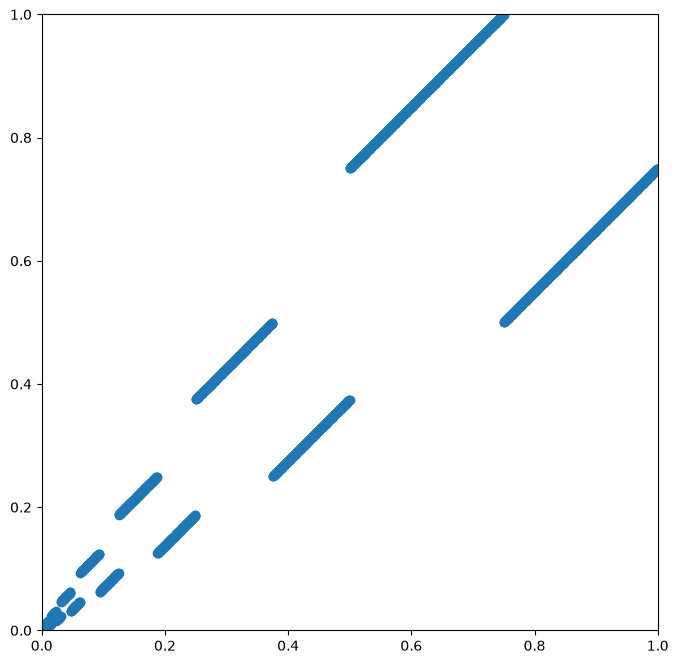

In [9]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(1,1,1)
set_unit_square(ax)
ax.plot(xs,ys, 'o')

To cover the domain correctly, we have to use the right dimensionality.

In [10]:
rng = ql.SobolRsg(2)

In [11]:
xs = []
ys = []
for i in range(2047):
    x,y = rng.nextSequence().value()
    xs.append(x)
    ys.append(y)
    

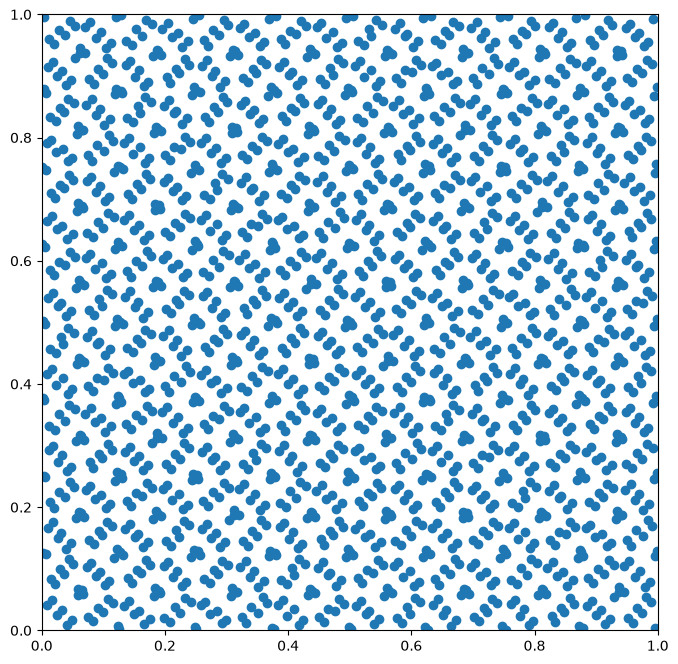

In [12]:
fig = plt.figure(figsize=(8,8))
ax =fig.add_subplot(1,1,1)
set_unit_square(ax)
ax.plot(xs, ys, 'o')

The pattern above covers the square evenly, and also causes projections on the two axes to have good coverage (which wouldn’t happen, for instance, with a regular placement in rows and columns; the projections of most points would coincide). It is also interesting to see how the coverage is built as the number of samples increase:

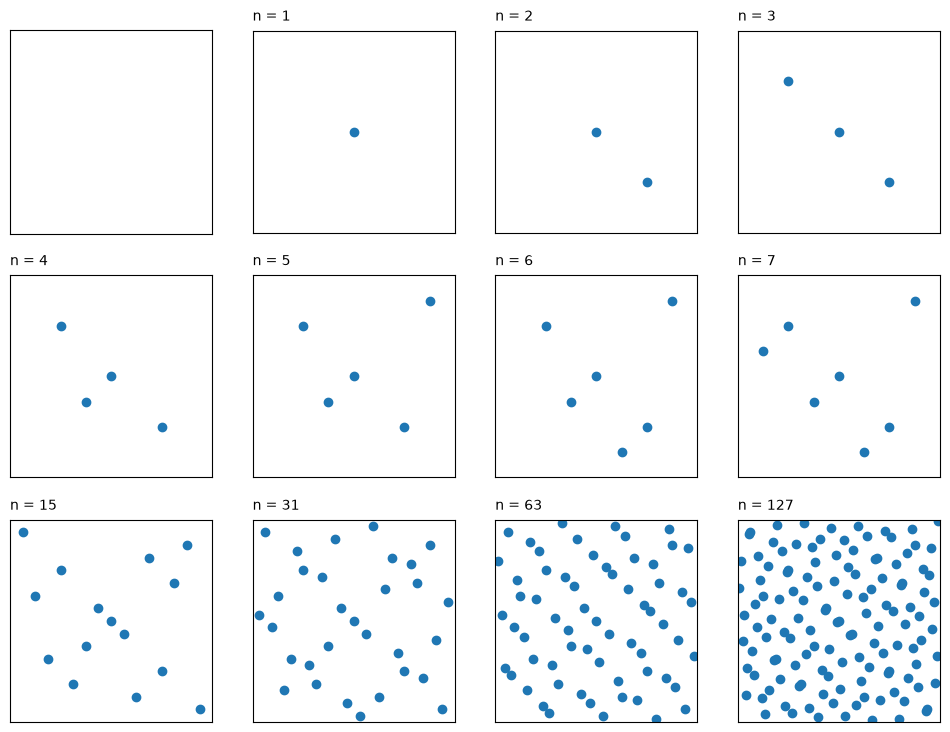

In [13]:
fig = plt.figure(figsize=(12,9))
for i, n in enumerate([0,1,2,3, 4,5,6,7, 15,31,63,127]):
    rng = ql.SobolRsg(2)
    ax = fig.add_subplot(3, 4, i+1)
    ax.set_xticks([])
    ax.set_yticks([])
    if n == 0:
        continue
    points = [rng.nextSequence().value() for j in range(n)]
    xs, ys = zip(*points)
    ax.axis('scaled')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.plot(xs, ys, 'o')
    ax.text(0.0, 1.05, 'n = %d' % n)

<h4>Dimensionality of Monte Carlo simulations</h4>

For instance, let’s say that you want to simulate three correlated stocks; and for sake of simplicity, let’s say they follow the Black-Scholes process. You’ll build a process for each of them...

In [14]:
today = ql.Date(27, ql.January, 2018)
ql.Settings.instance().evaluationDate = today
risk_free = ql.YieldTermStructureHandle(
    ql.FlatForward(today, 0.01, ql.Actual360())
)
processes = [
    ql.BlackScholesProcess(
        ql.QuoteHandle(ql.SimpleQuote(S)),
        risk_free,
        ql.BlackVolTermStructureHandle(
            ql.BlackConstantVol(today, ql.TARGET(), sigma, ql.Actual360())))
    for S, sigma in [(100, 0.20),
                     (80, 0.25),
                     (110, .18)]]


...and a single multi-dimensional process that correlates them. In this case, the resulting process has three random drivers.

In [15]:
rho =[[1.0, 0.6, 0.8],
      [0.6, 1.0, 0.4],
      [0.8, 0.4, 1.0]]

In [16]:
process = ql.StochasticProcessArray(processes, rho)
print(process.factors())

3


Now, let’s say that we want to simulate paths over four steps, starting from today and ending one year from now. Each sample of the Monte Carlo simulation will need three random number for
each step, for a total of 12 random numbers. This is the dimensionality of the problem; and, as I mentioned, the framework will check it and complain if it doesn’t match. (Please bear with me as I build the several classes needed for random-numbers generation. If find yourself doing this, you might want to write a helper function, like I do here.)

In [17]:
def rng(dimensionality):
    return ql.GaussianRandomSequenceGenerator(
        ql.UniformRandomSequenceGenerator(
            dimensionality,
            ql.UniformRandomGenerator(42)))
times =[0.25, 0.50, 0.75, 1.0]
#generator = ql.GaussianMultiPathGenerator(process, times, rng(10))

As you might expect, the thing works with the correct dimensionality:

In [18]:
generator = ql.GaussianMultiPathGenerator(process, times, rng(12))

In [19]:
sample = generator.next().value()


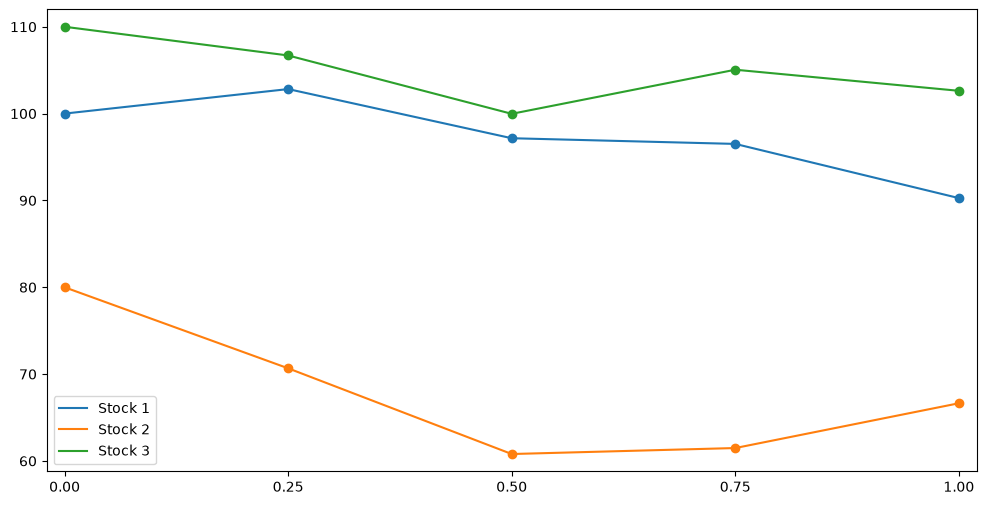

In [23]:
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(1,1,1)
ts = [0.0] + times
y_min = 80
y_max = 110
for i in range(3):
    p, = ax.plot(ts, sample[i], label='Stock %d' % (i+1))
    ax.plot(ts, sample[i], 'o', color=p.get_color())
    y_min = min(y_min, min(sample[i]))
    y_max = max(y_max, max(sample[i]))
ax.set_xlim(0.0-0.02, 1.0+0.02)
ax.set_xticks(ts)
ax.set_ylim(y_min-2, y_max+2)
ax.legend(loc='best');